# 📘 Machine Learning Metrics & Explainability Cheat Sheet

This notebook compiles essential concepts, formulas, and quick practical code examples from the key lectures:

---

## 🧠 Overview

| Lecture | Topic | Description |
|:--------:|:------|:-------------|
| **3** | **Supervised Learning Metrics** | Evaluation metrics for classification: Confusion Matrix, Accuracy, Precision, Recall, and F1-Score. Includes practical `scikit-learn` code and confusion matrix heatmaps. |
| **5** | **Explainability – SHAP & LIME** | Model-agnostic interpretation tools. Learn how to interpret local and global feature importance, visualize SHAP summary and waterfall plots, and compare SHAP vs LIME. |
| **7** | **Unsupervised Learning Metrics** | Internal & external metrics for clustering (K-Means): Silhouette, Davies-Bouldin, Inertia (Elbow), and Adjusted Mutual Information (AMI). Includes compact visual demos. |

---

# Lecture 3 — Performance Metrics for Classification

When evaluating classification models, it's essential to understand how well the model predicts categorical outcomes. We use:
- **TP** (True Positive), **TN** (True Negative), **FP** (False Positive), **FN** (False Negative)

---

## 3.1 Confusion Matrix

Binary case (extendable to multiclass):

|               | **Predicted Negative** | **Predicted Positive** |
|--------------:|:----------------------:|:----------------------:|
| **Actual Negative** | TN | FP |
| **Actual Positive** | FN | TP |

**Interpretation**
- **TP**: predicted positive & actually positive  
- **TN**: predicted negative & actually negative  
- **FP (Type I error)**: predicted positive but actually negative  
- **FN (Type II error)**: predicted negative but actually positive

---

## 3.2 Core Metrics & When to Use

### Accuracy
\begin{equation}
\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
\end{equation}

**Use when:** classes are fairly balanced and you need an overall correctness rate.  
**Caveat:** can be misleading with imbalanced datasets.

### Precision (Positive Predictive Value)
\begin{equation}
\mathrm{Precision}=\frac{TP}{TP+FP}
\end{equation}

**Use when:** cost of **false positives** is high (e.g., flagging a healthy patient as sick).  
**Caveat:** ignores false negatives.

### Recall (Sensitivity/TPR)
\begin{equation}
\mathrm{Recall}=\frac{TP}{TP+FN}
\end{equation}

**Use when:** cost of **false negatives** is high (e.g., missing a disease).  
**Caveat:** can be high while allowing many false positives.

### F1-Score (Harmonic Mean of Precision & Recall)
\begin{equation}
\mathrm{F1} = 2 \times \frac{\mathrm{Precision}\times\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
\end{equation}

**Use when:** need a balance between Precision and Recall, especially under class imbalance.  
**Caveat:** assumes equal importance of Precision and Recall.

---

## Practical Notes

- **Class imbalance:** Accuracy may hide poor minority-class performance—prefer Precision/Recall/F1 and **confusion matrix**.  
- **Averaging for multiclass:**  
  - **macro** — unweighted mean across classes (treats all classes equally)  
  - **weighted** — class-frequency–weighted mean (handles imbalance)  
  - **micro** — aggregates TP/FP/FN globally (good for overall performance)

---


In [1]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import numpy as np

def print_classification_metrics(y_true, y_pred, average='binary', pos_label=1):
    """
    Prints Accuracy, Precision, Recall, F1 and the Confusion Matrix.
    - For binary tasks: average='binary' and specify pos_label (default 1).
    - For multiclass tasks: use average in {'macro','weighted','micro'}.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, pos_label=pos_label if average=='binary' else None, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, pos_label=pos_label if average=='binary' else None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, pos_label=pos_label if average=='binary' else None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    # Optional detailed report (useful for multiclass)
    if average in {'macro','weighted','micro'} or len(np.unique(y_true)) > 2:
        print("\nClassification Report:\n")
        print(classification_report(y_true, y_pred, zero_division=0))


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix Heatmap"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if labels is None:
        labels = sorted(set(list(y_true) + list(y_pred)))
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False,
                xticklabels=[f"Pred {l}" for l in labels],
                yticklabels=[f"Actual {l}" for l in labels])
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Choosing the Right Metric

- **Email spam / fraud detection:** prioritize **Precision** to avoid false alarms; if missing positives is worse, prioritize **Recall**.
- **Medical screening:** prioritize **Recall** (catch all cases), then tune Precision with thresholds (Precision-Recall Curve).
- **Imbalanced data:** report **Precision, Recall, F1**, and show the **confusion matrix**. Consider **PR curves** and **ROC-AUC** as complementary tools.

**Thresholding tip:** Many classifiers output probabilities. Adjust the decision threshold to trade off Precision vs Recall to meet business goals.


Accuracy : 0.5140
Precision: 0.5167
Recall   : 0.7154
F1-Score : 0.6000

Confusion Matrix:
[[299 682]
 [290 729]]


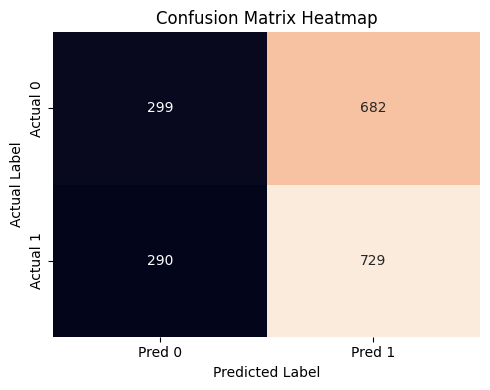

In [3]:
# Example demo (replace y_true/y_pred with your model outputs)
# Binary example
import numpy as np
rng = np.random.RandomState(0)
y_true = rng.randint(0, 2, size=2000)
y_pred = (rng.rand(2000) > 0.3).astype(int)  # dummy predictions

print_classification_metrics(y_true, y_pred, average='binary', pos_label=1)
plot_confusion_matrix(y_true, y_pred, labels=[0,1])

# Multiclass example (uncomment to try)
# y_true_mc = rng.randint(0, 3, size=1500)
# y_pred_mc = rng.randint(0, 3, size=1500)
# print_classification_metrics(y_true_mc, y_pred_mc, average='macro')
# plot_confusion_matrix(y_true_mc, y_pred_mc, labels=[0,1,2], title="Multiclass Confusion Matrix")


In [4]:
def summarize_multiclass(y_true, y_pred):
    for avg in ['macro','weighted','micro']:
        print(f"\n--- {avg.upper()} ---")
        print_classification_metrics(y_true, y_pred, average=avg)

# Example:
# summarize_multiclass(y_true_mc, y_pred_mc)



# Lecture 5 — Model Explainability: SHAP & LIME 

## SHAP (SHapley Additive exPlanations)
Based on Shapley values from game theory, assigning each feature a fair importance for a prediction.

**Why it’s useful**
- **Model-agnostic:** works with most models.
- **Local & Global:** explains a single prediction (local) and overall feature impact (global).
- **Fair attribution:** contributions sum to the prediction difference (additivity).
- **Great visuals:** summary, dependence, waterfall/force plots.

**Use cases**
- **Feature importance:** what drives predictions overall.
- **Fairness checks:** see if sensitive features influence predictions.
- **Debugging:** spot unexpected feature effects.

**Notes / Caveats**
- Can be **computationally heavy** on large data/complex models.
- Correlated features may **split credit** and complicate interpretation.
- Use the **right explainer** (Tree/Linear/Kernel) for efficiency & accuracy.

---

## LIME (Local Interpretable Model-Agnostic Explanations)
Approximates the model **locally** around one prediction with a simple, interpretable surrogate (often linear).

**Why it’s useful**
- **Human-readable local explanations** for single instances.
- **Model-agnostic & quick** to run.
- **Perturbation-based:** learns which features matter near the point.

**Use cases**
- **Explaining a single decision** (why this prediction?).
- **Model debugging:** where the black-box misbehaves.
- **Comparing models** on the same case.

**Notes / Caveats**
- Explains **only local behaviour**; can disagree with global patterns.
- **Instability:** random perturbations → slightly different explanations.
- Choice of **kernel width / sampling** affects results.

---

## SHAP vs LIME (at a glance)

| Aspect | **SHAP** | **LIME** |
|---|---|---|
| Explanation scope | Local **and** global | Local only |
| Theory | Shapley values (game theory) | Local surrogate via perturbations |
| Output | Consistent additive contributions | Surrogate model weights |
| Strengths | Accurate, fair, model-agnostic; great plots | Fast, simple, intuitive |
| Weaknesses | Computationally intensive | Only local; can be unstable |

**Guidance**
- Need **auditable, fair, consistent** attributions and global view → **SHAP**.  
- Need a **quick, human-readable** reason for one prediction → **LIME**.

---


### Practical workflow recipes

**SHAP (tree models)**
1) Fit your model (e.g., RandomForest/LightGBM/XGBoost).
2) Use `shap.TreeExplainer(model)` and `explainer.shap_values(X)`.
3) Plot global summary and a single-case waterfall.

**SHAP (general models)**
- Use `shap.Explainer(model.predict, data)` or `KernelExplainer` for pure black boxes.
- Subsample background data to reduce cost.

**LIME (tabular)**
1) Create `LimeTabularExplainer` with training data, feature names, class names.
2) Call `explain_instance(x_i, model.predict_proba)` for a case.
3) Show local weights and the surrogate’s fidelity.


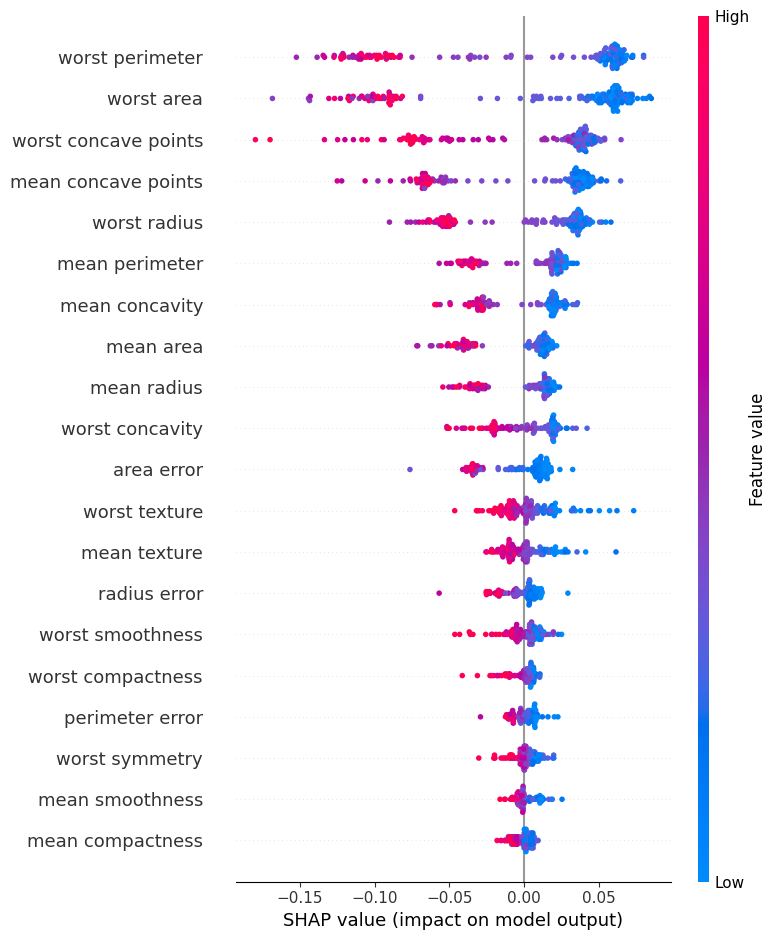

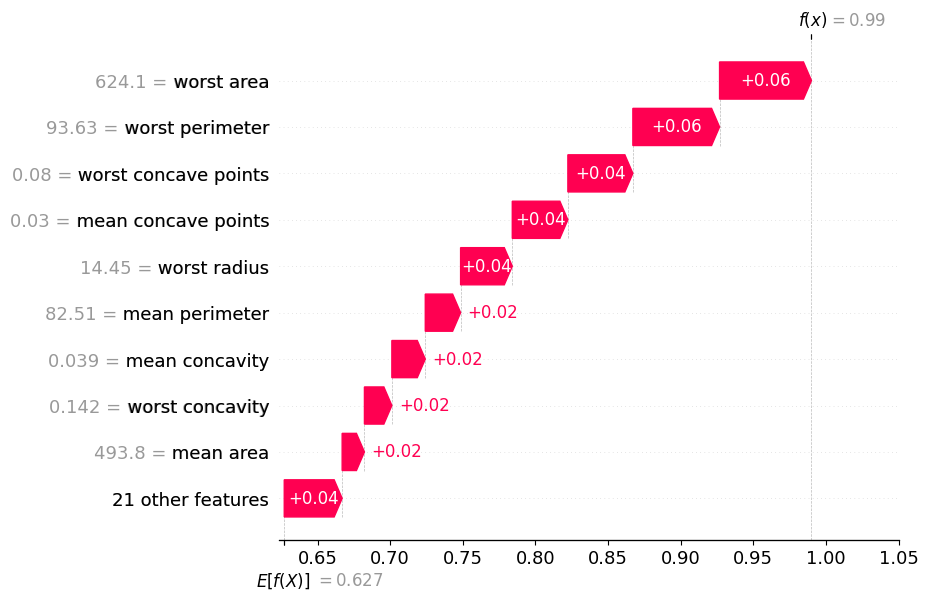

In [5]:
# --- Simple SHAP Example (Classification, self-contained) ---

# Install if needed
# %pip install shap

import shap
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# SHAP explainer (TreeExplainer is efficient for tree models)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

import numpy as np
classes = getattr(model, "classes_", np.array([0, 1]))
pos_idx = int(np.where(classes == 1)[0][0]) if 1 in classes else 0

# --- slice shap values correctly for plotting ---
if isinstance(shap_values, (list, tuple)):
    sv_global = shap_values[pos_idx]                 # (n_samples, n_features)
else:
    # 3D array: (n_samples, n_features, n_outputs)
    sv_global = shap_values[:, :, pos_idx]           # (n_samples, n_features)

# expected value (scalar) for the chosen class
ev = explainer.expected_value
base_val = ev[pos_idx] if np.ndim(ev) > 0 else ev

# Global summary
shap.summary_plot(sv_global, X_test, feature_names=feature_names, show=True)

# Local waterfall for one row
i = 0
shap.plots.waterfall(
    shap.Explanation(
        values=sv_global[i],
        base_values=float(base_val),
        data=X_test[i],
        feature_names=feature_names
    ),
    max_display=10
)

In [6]:
# %pip install -q lime
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
feature_names = X.columns
class_names = ["benign","malignant"]

Xtr, Xte, ytr, yte = train_test_split(X.values, y.values, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(Xtr, ytr)

explainer = LimeTabularExplainer(
    training_data=Xtr,
    feature_names=list(feature_names),
    class_names=class_names,
    discretize_continuous=True,
    mode='classification',
    random_state=42,
)

i = 0  # pick a test example
exp = explainer.explain_instance(
    data_row=Xte[i],
    predict_fn=model.predict_proba,
    num_features=10
)
# Show HTML in notebook (or use exp.as_list() for text)
try:
    exp.show_in_notebook(show_table=True)
except Exception:
    # Fallback: print the weights
    print("Local explanation (feature, weight):")
    for f, w in exp.as_list():
        print(f"{f:50s}  {w:+.4f}")


Local explanation (feature, weight):
516.83 < worst area <= 683.95                       +0.0784
83.88 < worst perimeter <= 97.62                    +0.0764
0.06 < worst concave points <= 0.10                 +0.0511
13.02 < worst radius <= 14.91                       +0.0424
0.02 < mean concave points <= 0.03                  +0.0410
worst smoothness > 0.15                             -0.0228
74.72 < mean perimeter <= 86.04                     +0.0210
413.30 < mean area <= 544.05                        +0.0204
0.11 < worst concavity <= 0.23                      +0.0172
0.32 < radius error <= 0.47                         +0.0163


### Interpretation Tips & Pitfalls

- **Correlated features:** attributions can split/shift importance; consider grouping or decorrelating features.
- **Sampling choices (LIME) / background data (SHAP):** strongly affect explanations—document them.
- **Local ≠ Global:** don’t generalize a single LIME explanation to the whole dataset.
- **Stability checks:** rerun with different seeds/perturbation sizes; explanations should be consistent.
- **Ethics & fairness:** inspect contributions of sensitive features; test counterfactuals.


**If you need…**
- **Auditable global insights + fair additivity → use SHAP.**
- **A quick, human-readable story for one case → use LIME.**
- **Very large tree models → SHAP(TreeExplainer) with sampled background.**
- **Arbitrary black-box (NLP/CV/tabular) → LIME or SHAP(Kernel/Explainer) with care on runtime.**


# Lecture 7 — Unsupervised Metrics

**Internal metrics** (no ground-truth labels):
- **Silhouette** ↑ better: mean similarity to own cluster vs. nearest other.
- **Davies–Bouldin (DB)** ↓ better: average “similarity” between clusters.
- **Inertia (K-Means)** ↓ better: sum of squared distances to centroids (use for Elbow).

**External metrics** (need true labels):
- **ARI (Adjusted Rand Index)** ↑ better, chance-adjusted.
- **AMI (Adjusted Mutual Information)** ↑ better, chance-adjusted.

**Choosing K (quick guide):**
- Try a range of K and compare **Silhouette↑**, **DB↓**, and Elbow on **Inertia↓**.


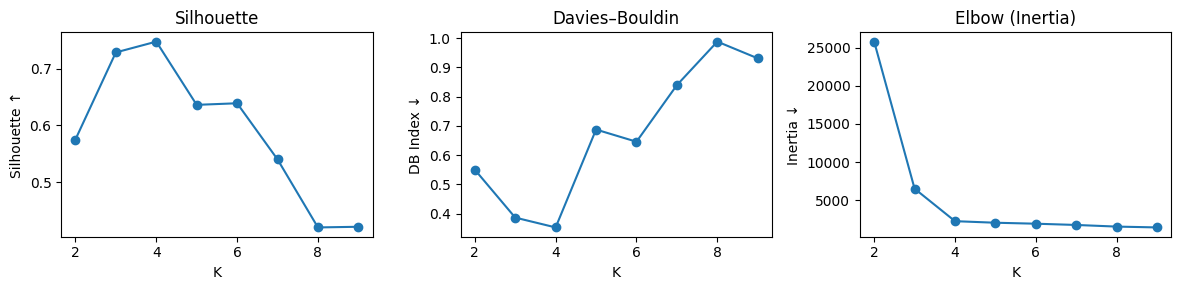

Best K by Silhouette: 4
Silhouette: 0.747
Davies–Bouldin: 0.353
Inertia: 2252.5

External metrics (using true labels from this toy set):
ARI: 0.997
AMI: 0.994


In [7]:
# --- Unsupervised Metrics: compact end-to-end demo ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)

# 1) Toy data (with true labels only for optional external metrics)
X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=1.2, random_state=42)

# 2) Scan K and compute internal metrics
Ks = range(2,  nine := 10)  # K=2..9
sil, dbi, inertia = [], [], []

for k in Ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    yk = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, yk))
    dbi.append(davies_bouldin_score(X, yk))

# 3) Plot (keep it minimal)
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
plt.plot(list(Ks), sil, marker='o'); plt.xlabel('K'); plt.ylabel('Silhouette ↑'); plt.title('Silhouette')
plt.subplot(1,3,2)
plt.plot(list(Ks), dbi, marker='o'); plt.xlabel('K'); plt.ylabel('DB Index ↓'); plt.title('Davies–Bouldin')
plt.subplot(1,3,3)
plt.plot(list(Ks), inertia, marker='o'); plt.xlabel('K'); plt.ylabel('Inertia ↓'); plt.title('Elbow (Inertia)')
plt.tight_layout(); plt.show()

# 4) Pick a K (simple heuristic: max silhouette)
best_k = int(Ks[int(np.argmax(sil))])
print(f"Best K by Silhouette: {best_k}")

# 5) Fit final model and report metrics
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
y_kmeans = kmeans.fit_predict(X)

print(f"Silhouette: {silhouette_score(X, y_kmeans):.3f}")
print(f"Davies–Bouldin: {davies_bouldin_score(X, y_kmeans):.3f}")
print(f"Inertia: {kmeans.inertia_:.1f}")

# 6) External metrics (ignore if no ground truth available)
print("\nExternal metrics (using true labels from this toy set):")
print(f"ARI: {adjusted_rand_score(y_true, y_kmeans):.3f}")
print(f"AMI: {adjusted_mutual_info_score(y_true, y_kmeans):.3f}")


- **Silhouette** in \([-1,1]\) (near **1** is best).  
- **DB** ≥ 0 (near **0** is best).  
- **Elbow**: look for the bend in **Inertia** vs. **K**.
